In [1]:
import pandas as pd
import numpy as np

In [4]:
#load data , file_path = "Salary_dataset.csv"
df = pd.read_csv("Salary_dataset.csv")
print(df)


    Unnamed: 0  YearsExperience    Salary
0            0              1.2   39344.0
1            1              1.4   46206.0
2            2              1.6   37732.0
3            3              2.1   43526.0
4            4              2.3   39892.0
5            5              3.0   56643.0
6            6              3.1   60151.0
7            7              3.3   54446.0
8            8              3.3   64446.0
9            9              3.8   57190.0
10          10              4.0   63219.0
11          11              4.1   55795.0
12          12              4.1   56958.0
13          13              4.2   57082.0
14          14              4.6   61112.0
15          15              5.0   67939.0
16          16              5.2   66030.0
17          17              5.4   83089.0
18          18              6.0   81364.0
19          19              6.1   93941.0
20          20              6.9   91739.0
21          21              7.2   98274.0
22          22              8.0  1

In [5]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [6]:
# Remove unnecessary index column if present
#if "Unnamed: 0" in df.columns:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())


Dataset Preview:
   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


In [10]:
import numpy as np

In [9]:
#Features & target
X = df[["YearsExperience"]]   # Feature
y = df["Salary"]              # Target

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, random_state=42
)

In [13]:
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 24
Test size: 6


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# Model parameters
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 24380.20147947369
Slope: 9423.81532303098


In [17]:
# Prediction
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:

# Evaluation
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", MAE)
print("Mean Squared Error (MSE):", MSE)
print("Root Mean Squared Error (RMSE):", RMSE)
print("R2 Score:", R2)


Mean Absolute Error (MAE): 6286.453830757745
Mean Squared Error (MSE): 49830096.855908334
Root Mean Squared Error (RMSE): 7059.043621901506
R2 Score: 0.9024461774180498


In [27]:
import matplotlib.pyplot as plt

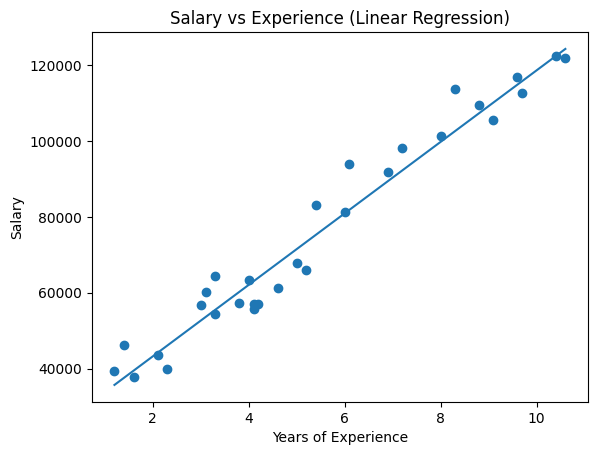

In [28]:
# Visualization
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience (Linear Regression)")
plt.show()

In [33]:
#Predict New Salary
exp = float(input("Enter years of experience: "))
pred_salary = model.predict([[exp]])
print("Predicted Salary:", pred_salary[0])

Predicted Salary: 307094.66117040307


c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


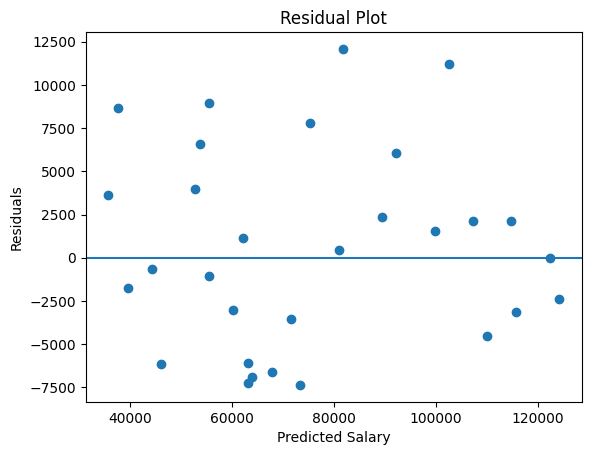

In [34]:
# Residuals
y_pred_all = model.predict(X)
residuals = y - y_pred_all

plt.scatter(y_pred_all, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()